# UK Politics

This dataset from Kaggle contains 3 datasets: one with speeches extracted from britishpolicalspeech.org (12k rows), one with speeches from ukpol.co.uk (350 rows) and one with the UK members of parliament since 1970, including party affiliation, obtained from Wikidata.

# Data exploratory

In [1]:
import pandas as pd
from tqdm import tqdm
import numpy as np
import nltk
from nltk.corpus import stopwords
nltk.download('stopwords')
nltk.download('punkt')

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.ensemble import RandomForestClassifier
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
import seaborn as sns

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\cbouton\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\cbouton\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


In [2]:
df_speeches = pd.read_csv('./data/speeches_ukpol.csv')
df_speeches.drop(columns=df_speeches.columns[0], axis=1, inplace=True)
df_speeches.head()

,Speaker,Year,Description,Speech
0,Diane Abbott,NaN,Below is the text of the speech made by Diane ...,The fact that the House of Commons has spent t...
1,Diane Abbott,2018.0,Below is the text of the speech made by Diane ...,Thank you Chair. Thank you Conference. It’s gr...
2,Diane Abbott,2019.0,Below is the text of the speech made by Diane ...,I thank the Home Secretary for his account of ...
3,Diane Abbott,2020.0,Below is the text of the speech made by Diane ...,"We live in extraordinary times. Unfortunately,..."
4,Diane Abbott,2020.0,Below is the text of the speech made by Diane ...,Like my good friend the right hon. Member for ...


In [3]:
df_speakers = pd.read_csv('./data/MPs_1970_onwards.csv')
df_speakers.head()

,item,itemLabel,constituencyLabel,partyLabel,start,electionLabel,end,endcauseLabel,noteLabel
0,http://www.wikidata.org/entity/Q265935,Nick Brown,Newcastle upon Tyne East,independent politician,2022-09-07T00:00:00Z,2019 United Kingdom general election,NaN,NaN,NaN
1,http://www.wikidata.org/entity/Q580464,Penny Mordaunt,NaN,NaN,2022-09-06T00:00:00Z,NaN,NaN,NaN,NaN
2,http://www.wikidata.org/entity/Q303299,Tobias Ellwood,Bournemouth East,independent politician,2022-07-19T00:00:00Z,NaN,NaN,NaN,NaN
3,http://www.wikidata.org/entity/Q575266,Christopher Pincher,Tamworth,independent politician,2022-06-30T00:00:00Z,NaN,NaN,NaN,NaN
4,http://www.wikidata.org/entity/Q19883135,Patrick Grady,Glasgow North,independent politician,2022-06-26T00:00:00Z,NaN,NaN,NaN,NaN


In [4]:
def binarize_party(label: str) -> int|None:
    if label == 'Labour Party':
        return 0
    elif label == 'Conservative Party':
        return 1
    else:
        return None

In [5]:
df_speakers['party'] = df_speakers['partyLabel'].apply(binarize_party)

In [6]:
df_speakers = df_speakers[['itemLabel', 'party']].groupby('itemLabel').mean().reset_index()
df_speakers = df_speakers[df_speakers['party'].isin([0, 1, np.nan])]

In [7]:
df_speakers.rename(columns={'itemLabel': 'Speaker'}, inplace=True)

In [8]:
df_merged = pd.merge(df_speeches, df_speakers, on='Speaker')

In [9]:
indexes_to_drop = [275, 429, 1575, 1929, 1930, 1931, 3309, 3310, 3629, 3688, 4686, 4842, 4994, 5474, 5475, 5508, 5526, 5581, 5597, 5601, 5611, 6097, 6279, 6609, 7820, 8192, 8289]
df_merged = df_merged.drop(index=indexes_to_drop)

In [10]:
df_merged = df_merged.dropna(subset=['Speaker', 'Speech'])
df_merged = df_merged[(df_merged['Speaker'] != '') & (df_merged['Speech'] != '') & (df_merged['party'] != '')]
df_merged = df_merged[df_merged['Year'] >= 1970]

In [11]:
len(df_merged)

9919

# Preprocessing NLP

Extracting the speeches column

In [12]:
speeches = df_merged['Speech'].values.tolist()

In [13]:
speeches = [element.lower() for element in speeches]

Splitting the words for each speech

In [14]:
def tokenize(speeches: list[str]) -> list[list[str]]:
    speeches_token = []
    for speech in tqdm(speeches):
        speeches_token.append(nltk.tokenize.word_tokenize(speech))
    return speeches_token

In [15]:
speeches = tokenize(speeches)

100%|██████████| 9919/9919 [01:08<00:00, 144.05it/s]


Removing stopwords

In [16]:
def remove_stopwords(speeches: list[list[str]]) -> list[list[str]]:
    stop_words = stopwords.words('english')
    speeches_filtered = []
    for speech in tqdm(speeches):
        tokens = []
        for w in speech:
            if w not in stop_words and len(w) > 2 and w.isalpha():
                tokens.append(w)
        speeches_filtered.append(tokens)
    return speeches_filtered

In [17]:
speeches = remove_stopwords(speeches)

100%|██████████| 9919/9919 [00:22<00:00, 432.74it/s]


Stemming

In [18]:
def stem(speeches: list[list[str]]) -> list[list[str]]:
    speeches_stem = []
    stemmer = nltk.SnowballStemmer('english')
    for speech in tqdm(speeches):
        tokens = []
        for w in speech:
            tokens.append(stemmer.stem(w))
        speeches_stem.append(tokens)
    return speeches_stem

In [19]:
speeches = stem(speeches)

100%|██████████| 9919/9919 [01:20<00:00, 123.80it/s]


# Vectorization

In [20]:
speeches = [" ".join(token) for token in speeches]

In [21]:
data = pd.DataFrame({'party': df_merged['party'], 'speech': speeches})
data.sample(10, random_state=99)

,party,speech
8177,1.0,statutori instrument laid septemb titl motor v...
3650,1.0,rapid test vital part roadmap help cautious li...
233,0.0,virus gone away could easili get control witho...
8301,1.0,thank much deputi speaker transpar make hous a...
10018,1.0,welcom session delight david davi shailesh var...
7147,1.0,permiss would like make statement first want b...
6526,0.0,busi across face black hole winter billion wip...
8437,1.0,alway prepar justifi vote parliament account c...
1225,1.0,prime minist thank well thank welcom great sie...
2393,NaN,echo comment hon friend member swansea east ca...


In [22]:
test = data[data['party'].isna()]
test.head()

,party,speech
71,NaN,introduct thank point first cabinet minist hig...
73,NaN,subject open misunderstand misrepresent public...
74,NaN,introduct delight launch credit union stornowa...
76,NaN,wish updat hous progress reform public servic ...
79,NaN,good morn give great pleasur open breakfast me...


In [23]:
len(test)

1018

In [24]:
data = data[data['party'].notna()]

In [25]:
len(data)

8901

In [26]:
train, val = train_test_split(data, test_size=0.2, shuffle=True, random_state=50, stratify=data['party'])

In [27]:
y_train = train['party']
X_train = train['speech']

y_val = val['party']
X_val = val['speech']

In [28]:
vectorizer = TfidfVectorizer()
X_train = vectorizer.fit_transform(X_train)
X_train = pd.DataFrame(X_train.toarray(), columns=vectorizer.get_feature_names_out())
len(X_train)

7120

In [29]:
X_val = vectorizer.transform(X_val)
X_val = pd.DataFrame(X_val.toarray(), columns=vectorizer.get_feature_names_out())
len(X_val)

1781

In [30]:
X_test = vectorizer.transform(test['speech'])
X_test = pd.DataFrame(X_test.toarray(), columns=vectorizer.get_feature_names_out())
len(X_test)

1018

# Building the model

In [31]:
model = RandomForestClassifier(n_jobs=-1)
model.fit(X_train, y_train)

RandomForestClassifier(n_jobs=-1)

In [32]:
y_pred = model.predict(X_train)
print(classification_report(y_train, y_pred))

              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00      2229
         1.0       1.00      1.00      1.00      4891

    accuracy                           1.00      7120
   macro avg       1.00      1.00      1.00      7120
weighted avg       1.00      1.00      1.00      7120



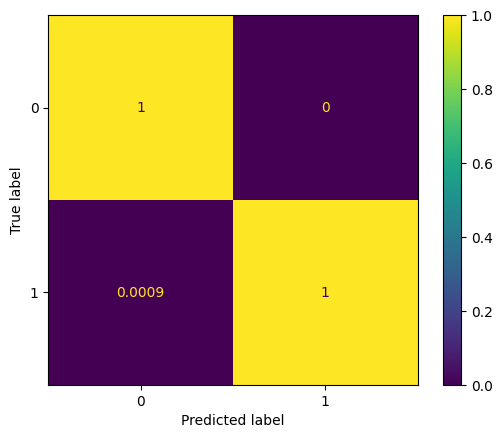

In [33]:
ConfusionMatrixDisplay(confusion_matrix(y_train, y_pred, labels=model.classes_, normalize='pred')).plot()

In [34]:
y_pred = model.predict(X_val)
print(classification_report(y_val, y_pred))

              precision    recall  f1-score   support

         0.0       0.91      0.46      0.61       557
         1.0       0.80      0.98      0.88      1224

    accuracy                           0.82      1781
   macro avg       0.86      0.72      0.75      1781
weighted avg       0.84      0.82      0.80      1781



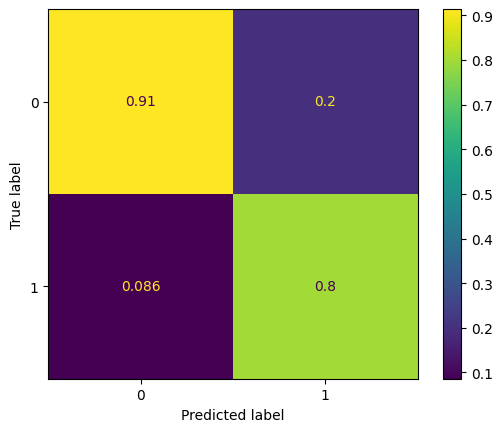

In [35]:
ConfusionMatrixDisplay(confusion_matrix(y_val, y_pred, labels=model.classes_, normalize='pred')).plot()

In [36]:
y_pred_train = model.predict_proba(X_train)
y_pred_train[:5]

array([[0.81, 0.19],
       [0.07, 0.93],
       [0.93, 0.07],
       [0.11, 0.89],
       [0.07, 0.93]])

In [37]:
y_pred_val = model.predict_proba(X_val)
y_pred_val[:5]

array([[0.21, 0.79],
       [0.85, 0.15],
       [0.43, 0.57],
       [0.18, 0.82],
       [0.32, 0.68]])

In [38]:
y_pred_test = model.predict_proba(X_test)
y_pred_test[:5]

array([[0.26, 0.74],
       [0.32, 0.68],
       [0.12, 0.88],
       [0.28, 0.72],
       [0.23, 0.77]])

In [39]:
feature_importances_df = pd.DataFrame({'Feature': model.feature_names_in_, 'Importance': model.feature_importances_})
feature_importances_df = feature_importances_df[feature_importances_df['Importance'] != 0]

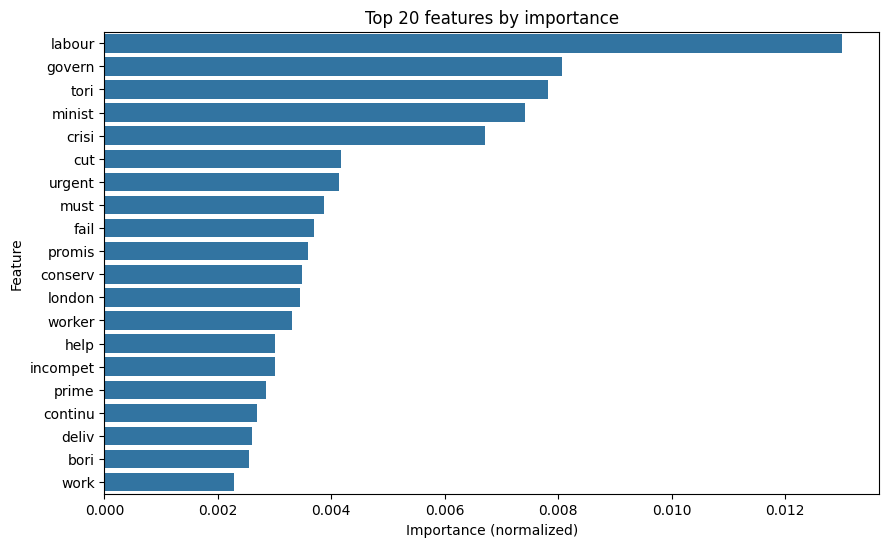

In [40]:
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importances_df.sort_values('Importance', ascending=False).head(20), orient='h')
plt.xlabel('Importance (normalized)')
plt.ylabel('Feature')
plt.title('Top 20 features by importance')
plt.show()

# Results analysis

In [41]:
def pred_to_df(preds: np.ndarray, df: pd.DataFrame) -> pd.DataFrame:
    df['pred'] = [pred[1] for pred in preds]
    return df

In [42]:
train = pred_to_df(y_pred_train, train)
train.head()

,party,speech,pred
5483,0.0,year come hous work printer news world later s...,0.19
9621,1.0,earli depart educ chang way teacher qualifi ov...,0.93
3236,0.0,conserv stealth cut school budget show disrega...,0.07
4089,1.0,thank ask speak today british chamber commerc ...,0.89
8357,1.0,delight nottingham trent univers ntu morn make...,0.93


In [43]:
val = pred_to_df(y_pred_val, val)
val.head()

,party,speech,pred
5461,1.0,friday august million custom affect major powe...,0.79
8626,0.0,govern month sort exam forc screech day confus...,0.15
4041,1.0,rise today pay tribut behalf constitu alreadi ...,0.57
207,1.0,lord amend hous today relat nhs workforc recon...,0.82
4066,1.0,begin deputi speaker echo remark hon friend me...,0.68


In [44]:
test = pred_to_df(y_pred_test, test)
test.head()

,party,speech,pred
71,NaN,introduct thank point first cabinet minist hig...,0.74
73,NaN,subject open misunderstand misrepresent public...,0.68
74,NaN,introduct delight launch credit union stornowa...,0.88
76,NaN,wish updat hous progress reform public servic ...,0.72
79,NaN,good morn give great pleasur open breakfast me...,0.77


In [45]:
output = pd.concat([train, val, test], axis=0)
output.head()

,party,speech,pred
5483,0.0,year come hous work printer news world later s...,0.19
9621,1.0,earli depart educ chang way teacher qualifi ov...,0.93
3236,0.0,conserv stealth cut school budget show disrega...,0.07
4089,1.0,thank ask speak today british chamber commerc ...,0.89
8357,1.0,delight nottingham trent univers ntu morn make...,0.93


In [46]:
output = pd.merge(output, df_merged['Speaker'], left_index=True, right_index=True)
output

,party,speech,pred,Speaker
5483,0.0,year come hous work printer news world later s...,0.19,Ron Leighton
9621,1.0,earli depart educ chang way teacher qualifi ov...,0.93,Robin Walker
3236,0.0,conserv stealth cut school budget show disrega...,0.07,Kate Green
4089,1.0,thank ask speak today british chamber commerc ...,0.89,Michael Howard
8357,1.0,delight nottingham trent univers ntu morn make...,0.93,Chris Skidmore
...,...,...,...,...
9974,NaN,beg move leav given bring bill make provis hou...,0.72,Pete Wishart
9975,NaN,none minist acknowledg visa carnet render tour...,0.48,Pete Wishart
9977,NaN,thank madam deputi speaker heed appropri warn ...,0.67,John Woodcock
9978,NaN,privileg follow heartfelt speech also coincid ...,0.61,John Woodcock


In [47]:
df_speakers = pd.read_csv('./data/MPs_1970_onwards.csv')

In [48]:
df_speakers.drop_duplicates(subset='itemLabel', inplace=True)

In [49]:
df_speakers.rename(columns={'itemLabel': 'Speaker'}, inplace=True)
df_speakers.head()

,item,Speaker,constituencyLabel,partyLabel,start,electionLabel,end,endcauseLabel,noteLabel
0,http://www.wikidata.org/entity/Q265935,Nick Brown,Newcastle upon Tyne East,independent politician,2022-09-07T00:00:00Z,2019 United Kingdom general election,NaN,NaN,NaN
1,http://www.wikidata.org/entity/Q580464,Penny Mordaunt,NaN,NaN,2022-09-06T00:00:00Z,NaN,NaN,NaN,NaN
2,http://www.wikidata.org/entity/Q303299,Tobias Ellwood,Bournemouth East,independent politician,2022-07-19T00:00:00Z,NaN,NaN,NaN,NaN
3,http://www.wikidata.org/entity/Q575266,Christopher Pincher,Tamworth,independent politician,2022-06-30T00:00:00Z,NaN,NaN,NaN,NaN
4,http://www.wikidata.org/entity/Q19883135,Patrick Grady,Glasgow North,independent politician,2022-06-26T00:00:00Z,NaN,NaN,NaN,NaN


In [50]:
output = pd.merge(output, df_speakers[['partyLabel', 'Speaker']], on='Speaker')
output.head()

,party,speech,pred,Speaker,partyLabel
0,0.0,year come hous work printer news world later s...,0.19,Ron Leighton,Labour Party
1,1.0,earli depart educ chang way teacher qualifi ov...,0.93,Robin Walker,Conservative Party
2,0.0,conserv stealth cut school budget show disrega...,0.07,Kate Green,Labour Party
3,1.0,thank ask speak today british chamber commerc ...,0.89,Michael Howard,Conservative Party
4,1.0,delight nottingham trent univers ntu morn make...,0.93,Chris Skidmore,Conservative Party


In [51]:
grouped_parties = output.groupby('partyLabel')['pred'].median().to_frame().reset_index()
grouped_parties

,partyLabel,pred
0,Alba Party,0.6000
1,Alliance Party of Northern Ireland,0.8000
2,Change UK,0.8625
3,Conservative Party,0.9100
4,Democratic Unionist Party,0.7100
5,Green Party of England and Wales,0.5500
6,Labour Co-operative,0.4600
7,Labour Party,0.2200
8,Liberal Democrats,0.6800
9,Liberal Party,0.7650


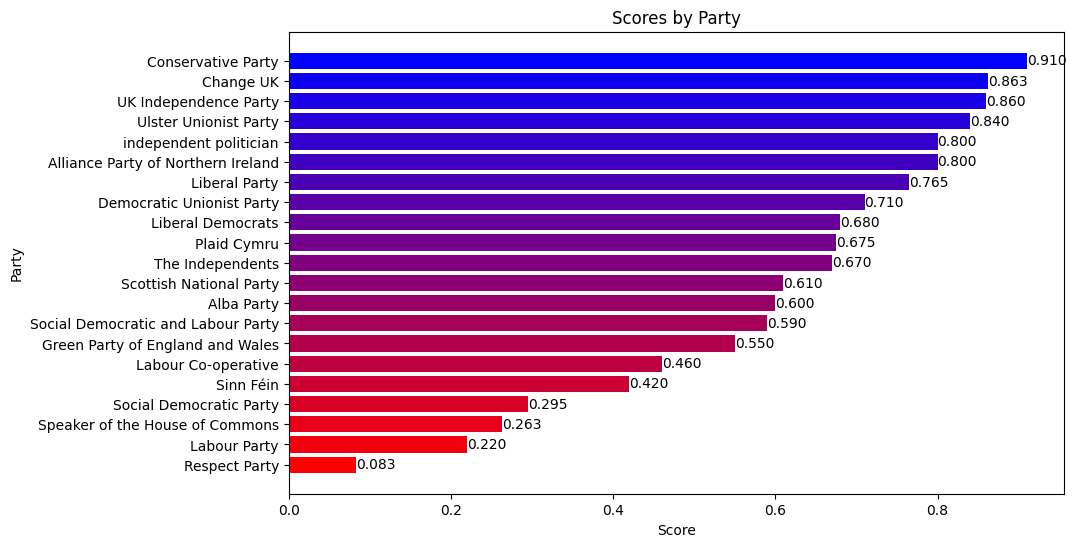

In [52]:
df = pd.DataFrame(grouped_parties)

df_sorted = df.sort_values(by='pred')

cmap = LinearSegmentedColormap.from_list('red_blue', [(1, 0, 0), (0, 0, 1)], N=len(df_sorted))

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(df_sorted['partyLabel'], df_sorted['pred'], color=cmap(np.linspace(0, 1, len(df_sorted))))

for bar, pred in zip(bars, df_sorted['pred']):
    ax.text(bar.get_width(), bar.get_y() + bar.get_height() / 2, f'{pred:.3f}', va='center', ha='left')

ax.set_xlabel('Score')
ax.set_ylabel('Party')
ax.set_title('Scores by Party')

plt.show()

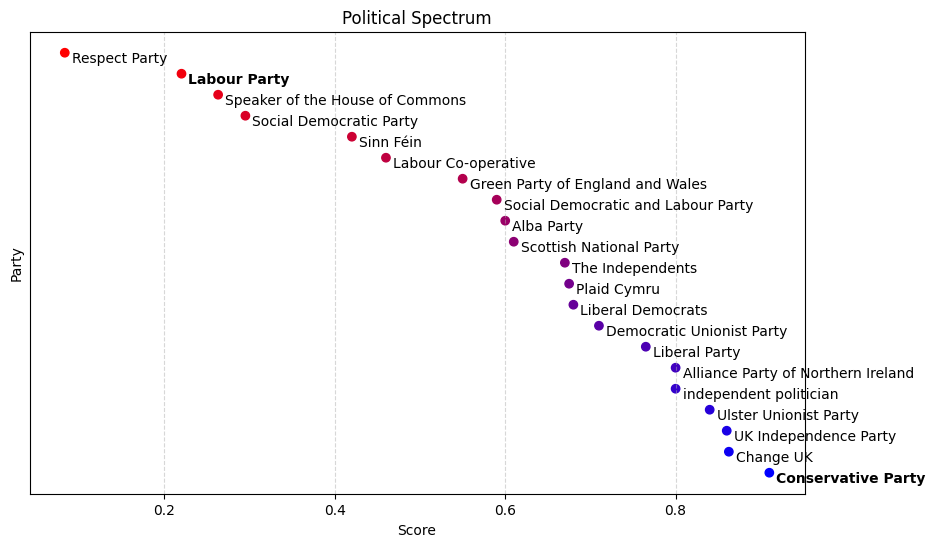

In [53]:
df = pd.DataFrame(grouped_parties)

df_sorted = df.sort_values(by='pred')

cmap = LinearSegmentedColormap.from_list('red_blue', [(1, 0, 0), (0, 0, 1)], N=len(df_sorted))

plt.figure(figsize=(10, 6))
plt.scatter(df_sorted['pred'], range(len(df_sorted)), c=range(len(df_sorted)), cmap=cmap)

for i, txt in enumerate(df_sorted['partyLabel']):
    if txt == 'Conservative Party' or txt == 'Labour Party':
        plt.annotate(txt, (df_sorted['pred'].iloc[i], i), xytext=(5, -7), textcoords='offset points', weight='bold')
    else:
        plt.annotate(txt, (df_sorted['pred'].iloc[i], i), xytext=(5, -7), textcoords='offset points')

plt.xlabel('Score')
plt.ylabel('Party')
plt.title('Political Spectrum')

plt.tick_params(axis='y', which='both', left=False, labelleft=False)
plt.grid(axis='x', alpha=0.5, linestyle='--')

plt.gca().invert_yaxis()

plt.show()